In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv("/content/loans_balanced_55_45.csv")

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Notes,Comments,TempCode,RawText
0,LP001835,Male,Yes,1,Graduate,No,6317.779471,4504.039220,82.289351,403.742212,0.734036,Rural,N,NaN,Cross-check income details.,TMP-7119,check
1,LP002234,Male,No,1,Graduate,No,15500.606139,1625.701736,67.482806,416.129423,0.910721,Semiurban,N,Data mismatch,Auto-clean required.,NaN,NaN
2,LP001136,Male,Yes,2,Not Graduate,Yes,-2970.353198,7053.563790,53.281877,465.888873,1.064589,Semiurban,Y,Pending verification,Customer called to confirm details.,TMP-8376,ok
3,LP002813,Female,Yes,NaN,Graduate,No,12157.655870,-520.711078,207.623000,411.119519,0.842643,Urban,N,Pending verification,Auto-clean required.,TMP-3503,NaN
4,LP001640,Female,Yes,2,Graduate,No,11035.059506,-309.411383,48.841168,359.178844,0.819314,Urban,N,NaN,Missing original documentation.,TMP-1634,not available


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,3130.000000,3130.000000,3023.000000,3060.000000,2910.000000
mean,5727.797699,1591.681325,145.972300,340.450171,0.843178
std,6182.610988,2943.790404,85.083032,65.891893,0.365608
min,-15743.239521,-10825.672365,-130.377257,127.553607,-0.432910
25%,1469.292603,-398.983666,88.931437,295.814716,0.598963
50%,5756.144803,1591.865887,146.438613,338.635275,0.849375
75%,9949.773264,3574.262830,202.973818,385.830332,1.088552
max,27881.736143,10716.195602,495.990937,623.535945,2.667610


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,66
Married,13
Dependents,72
Education,0
Self_Employed,161
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,107
Loan_Amount_Term,70


In [ ]:
df=df.drop(columns=["Notes","Comments","TempCode","RawText"])

In [ ]:
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
num_cols = ["LoanAmount", "Loan_Amount_Term"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df["LoanAmount"] = df["LoanAmount"].clip(9, 700)
df["ApplicantIncome"] = df["ApplicantIncome"].clip(150, 81000)
df["CoapplicantIncome"] = df["CoapplicantIncome"].clip(0, 41667)

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

/tmp/ipython-input-3434708264.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001835,Male,Yes,1,Graduate,No,6317.779471,4504.039220,82.289351,403.742212,0.734036,Rural,0
1,LP002234,Male,No,1,Graduate,No,15500.606139,1625.701736,67.482806,416.129423,0.910721,Semiurban,0
2,LP001136,Male,Yes,2,Not Graduate,Yes,150.000000,7053.563790,53.281877,465.888873,1.064589,Semiurban,1
3,LP002813,Female,Yes,0,Graduate,No,12157.655870,0.000000,207.623000,411.119519,0.842643,Urban,0
4,LP001640,Female,Yes,2,Graduate,No,11035.059506,0.000000,48.841168,359.178844,0.819314,Urban,0


In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
0,1803
2,538
1,534
3+,255


In [ ]:
df=df.replace(to_replace='3+',value=4)

In [ ]:

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].round()
valid_terms = np.array([360, 180, 120, 84, 60, 36])
def closest_term(x):
    return valid_terms[np.abs(valid_terms - x).argmin()]

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].apply(closest_term)

In [ ]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce").fillna(0).astype(int)
df["Dependents"] = df["Dependents"].clip(0, 3)

In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
0,1803
2,538
1,534
3,255


<Axes: xlabel='Education', ylabel='count'>

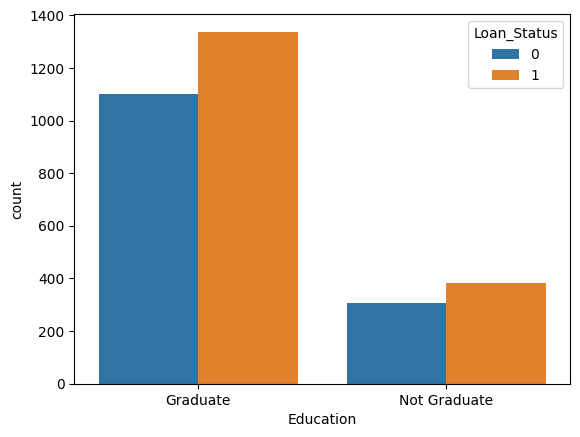

In [ ]:
sns.countplot(x='Education',hue='Loan_Status',data=df)

<Axes: xlabel='Married', ylabel='count'>

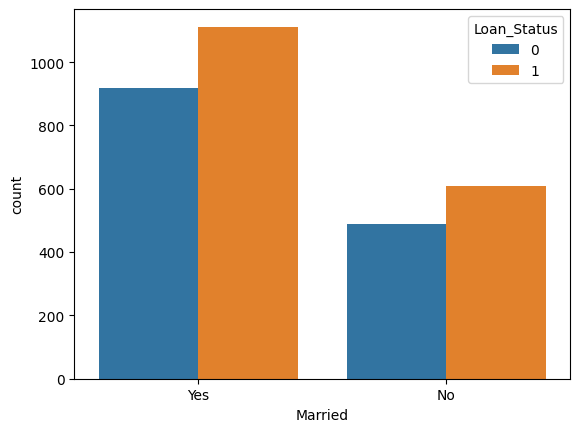

In [ ]:
sns.countplot(x="Married",hue="Loan_Status",data=df)

In [ ]:
df.replace({'Married':{'No':0,'Yes':1},'Education':{'Graduate':1,'Not Graduate':0},'Gender':{'Male':1,'Female':0},'Property_Area':{'Rural':0,'Urban':1,'Semiurban':2},'Self_Employed':{'No':0,'Yes':1}},inplace=True)

/tmp/ipython-input-3762609467.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Married':{'No':0,'Yes':1},'Education':{'Graduate':1,'Not Graduate':0},'Gender':{'Male':1,'Female':0},'Property_Area':{'Rural':0,'Urban':1,'Semiurban':2},'Self_Employed':{'No':0,'Yes':1}},inplace=True)


In [ ]:
df['Credit_History'] = df['Credit_History'].apply(lambda x: 1 if x > 0.5 else 0)
df['Dependents'] = df['Dependents'].astype(int)

In [ ]:
df["Loan_ID"] = [f"LN{i+1}" for i in range(len(df))]

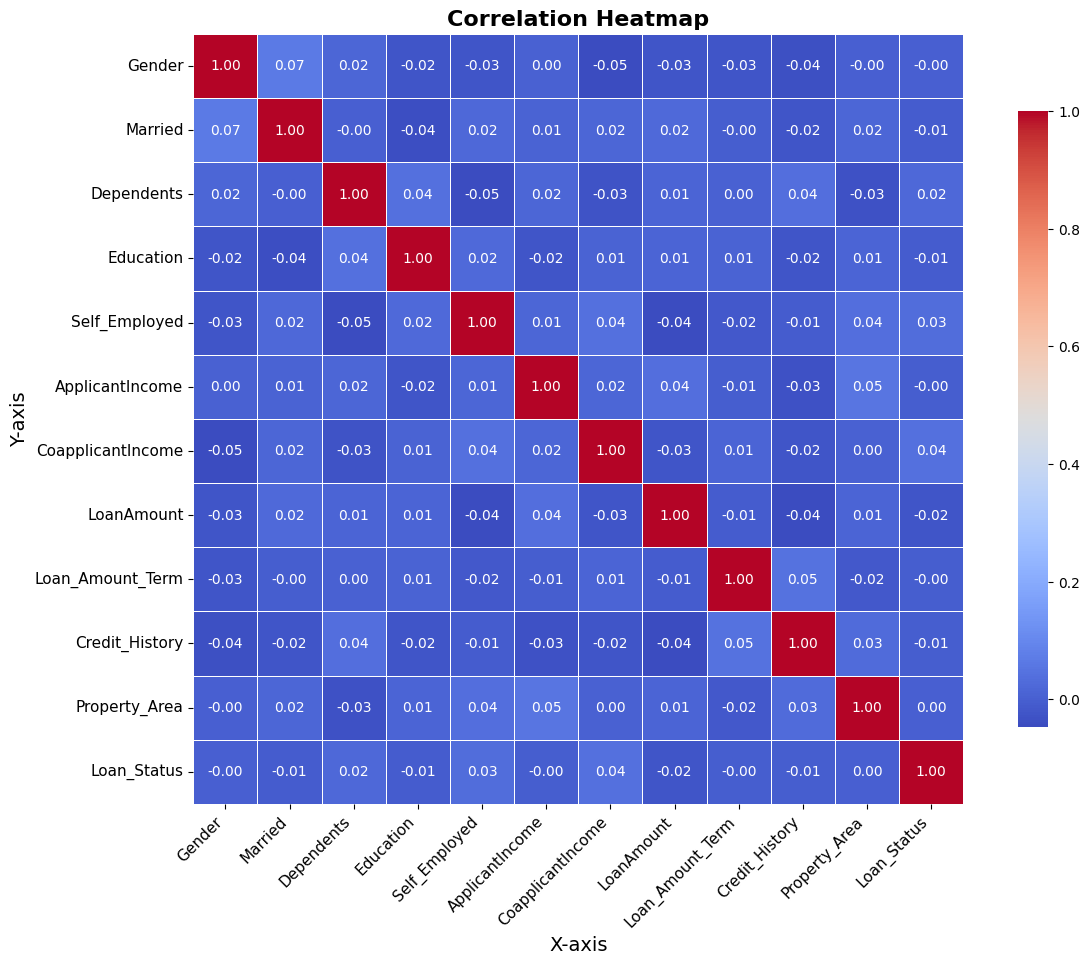

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("X-axis", fontsize=14)
plt.ylabel("Y-axis", fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.show()

In [ ]:
X=df.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y=df['Loan_Status']

In [ ]:
from sklearn.preprocessing import StandardScaler
continuous = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
scaler = StandardScaler()
df[continuous] = scaler.fit_transform(df[continuous])

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

In [ ]:
from sklearn.svm import LinearSVC
classifier = LinearSVC(max_iter=5000, random_state=2)

In [ ]:
classifier.fit(X_train,Y_train)

LinearSVC(max_iter=5000, random_state=2)

In [ ]:
X_train_pred=classifier.predict(X_train)
train_acc=accuracy_score(X_train_pred,Y_train)
print(train_acc)

0.5567092651757188


In [ ]:
X_test_pred=classifier.predict(X_test)
test_acc=accuracy_score(X_test_pred,Y_test)*100
print("Accuracy: ",test_acc)
test_prec = precision_score(Y_test, X_test_pred)*100
print("Precision:",test_prec)
test_recall = recall_score(Y_test, X_test_pred)*100
print("Recall:",test_recall)
test_f1 = f1_score(Y_test, X_test_pred)*100
print("f1-score:",test_f1)

Accuracy:  54.7923322683706
Precision: 55.195911413969334
Recall: 94.18604651162791
f1-score: 69.60257787325457


In [ ]:
from sklearn.ensemble import RandomForestClassifier

classifier1 = RandomForestClassifier(n_estimators=200, random_state=2)
classifier1.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=200, random_state=2)

In [ ]:
Y_pred = classifier1.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)*100
print("Random Forest Accuracy:", accuracy)
precision = precision_score(Y_test, Y_pred)*100
print("Random Forest Precision:", precision)
recall = recall_score(Y_test, Y_pred)*100
print("Random Forest Recall:", recall)


Random Forest Accuracy: 82.10862619808307
Random Forest Precision: 83.72093023255815
Random Forest Recall: 83.72093023255815


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2
)

xgb.fit(X_train, Y_train)
pred_xgb = xgb.predict(X_test)
xgb_accuracy=accuracy_score(Y_test, pred_xgb)*100
print("XGBoost Accuracy:", xgb_accuracy)
xgb_prec = precision_score(Y_test, pred_xgb)*100
print("XGBoost Precision:", xgb_prec)
xgb_recall = recall_score(Y_test, pred_xgb)*100
print("XGBoost recall:", xgb_recall)
xgb_f1 = f1_score(Y_test, pred_xgb)*100
print("XGBoost f1-score:", xgb_f1)

XGBoost Accuracy: 68.21086261980831
XGBoost Precision: 68.07980049875312
XGBoost recall: 79.36046511627907
XGBoost f1-score: 73.28859060402685


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
model_predictions = {
    "SVM": X_test_pred,
    "Random Forest": Y_pred,
    "XGBoost": pred_xgb
}
for name, pred in model_predictions.items():
    acc = accuracy_score(Y_test, pred)
    prec = precision_score(Y_test, pred)
    recall = recall_score(Y_test, pred)
    f1 = f1_score(Y_test, pred)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


SVM Performance:
Accuracy : 0.5479
Precision: 0.5520
Recall   : 0.9419
F1 Score : 0.6960

Random Forest Performance:
Accuracy : 0.8211
Precision: 0.8372
Recall   : 0.8372
F1 Score : 0.8372

XGBoost Performance:
Accuracy : 0.6821
Precision: 0.6808
Recall   : 0.7936
F1 Score : 0.7329


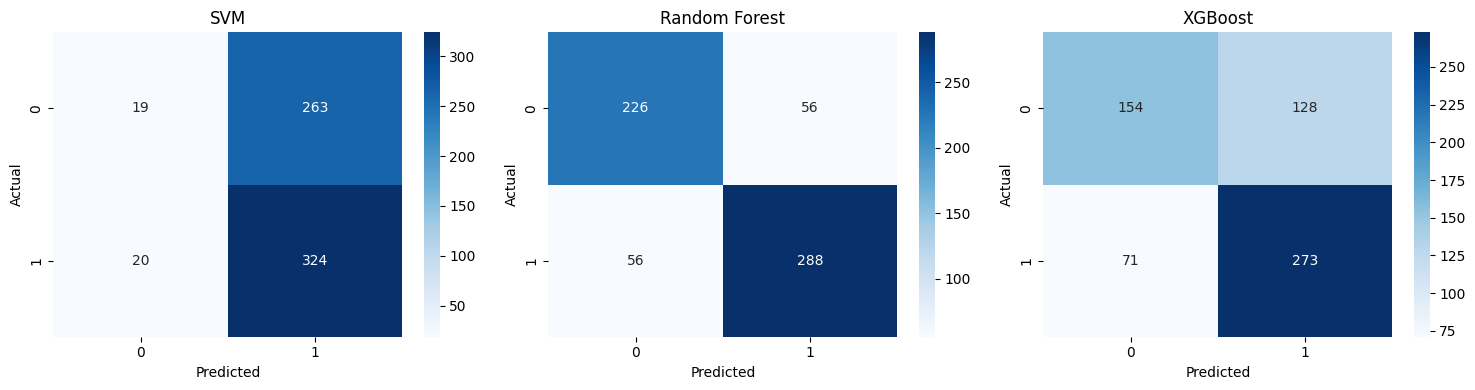

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
models = {
    "SVM": X_test_pred,
    "Random Forest": Y_pred,
    "XGBoost": pred_xgb
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(Y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

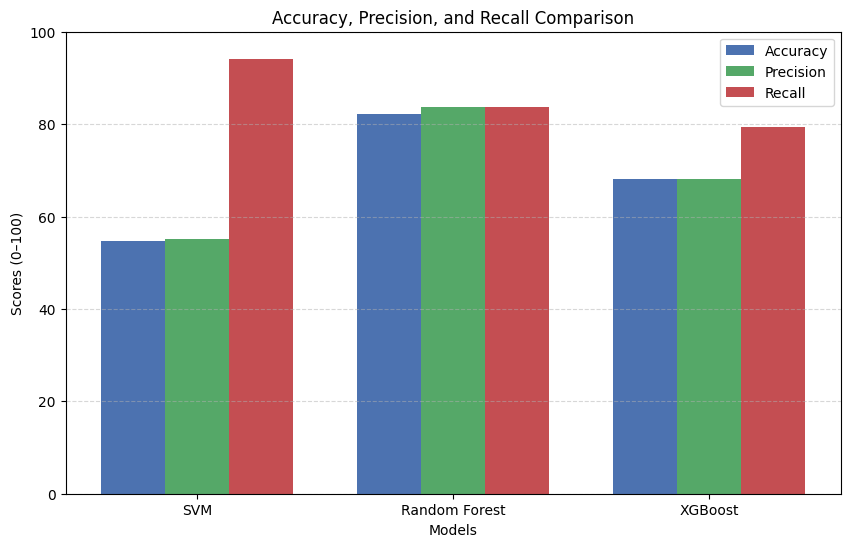

In [ ]:
accuracies = [test_acc, accuracy, xgb_accuracy]
precisions = [test_prec, precision, xgb_prec]
recalls = [test_recall, recall, xgb_recall]

models = ["SVM", "Random Forest", "XGBoost"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracies, width, label='Accuracy', color='#4C72B0')
plt.bar(x, precisions, width, label='Precision', color='#55A868')
plt.bar(x + width, recalls, width, label='Recall', color='#C44E52')

plt.xlabel("Models")
plt.ylabel("Scores (0–100)")
plt.title("Accuracy, Precision, and Recall Comparison")
plt.xticks(x, models)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

In [ ]:
import joblib

joblib.dump(classifier1, "model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(list(X.columns), "features.joblib")

['features.joblib']